<a href="https://colab.research.google.com/github/barroslfb/Atividade1_Estatistica/blob/main/LuizFelipeBarros_Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Universidade Federal de Pernambuco.

Recife, 22 de março de 2026.

Aluno: Luiz Felipe Pinto Ávila de Barros

---

ESTATÍSTICA E PROBABILIDADE PARA COMPUTAÇÃO

Nessa atividade, foram disponibilizadas duas tabelas, uma contendo dados de um aeroporto e uma com informações sobre clientes. Serão feitos dois estudos de caso, um para cada tabela.


In [99]:
# Importação das bibliotecas e do csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url_aero = 'https://raw.githubusercontent.com/barroslfb/Atividade1_Estatistica/refs/heads/main/dados_aeroporto.csv'
url_clientes = 'https://raw.githubusercontent.com/barroslfb/Atividade1_Estatistica/refs/heads/main/clientes_vendas.csv'
df_aero = pd.read_csv(url_aero)
df_clientes = pd.read_csv(url_clientes)

# **ESTUDO DE CASO #1**

Você recebeu dados operacionais de um aeroporto com registros de passageiros, voos e horários. A gestão deseja entender padrões de atraso, perfil de passageiros e uso dos portões para melhorar a operação diária.

Aplicar todas as etapas da análise descritiva:
- Limpeza e padronização
- Enriquecimento
- Criar faixas de horário (manhã, tarde, noite)
- Criar coluna binária para indicar se o passageiro está com embarque concluído

Organização

Tabelas cruzadas (ex. Companhia x Status)

Visualizações:
- Gráficos
Interpretação
Quais companhias concentram atrasos?
Qual o horário mais crítico?

**1ª ETAPA - Limpeza e padronização**

Como indicado pelas orientações do estudo de caso, irei começar realizando a limpeza e padronização dos dados. Observando a tabela, é visível diversas falhas como células vazias, linhas repetidas e falta de padronização nos dados. Dessa forma, irei realizar essa primeira análise utilizando a biblioteca Pandas:

In [100]:
# Observando a tabela
df_aero.head(10)

,passageiro,voo,companhia,origem,destino,status,horario_previsto,portao
0,joão,az123,AZUL,recife,Salvador,chegada,14:00,B2
1,Maria,Az123,azul,recife,salvador,CHEGADA,14:00,B2
2,maria,AZ123,AZUL,Recife,SALVADOR,chegada,14:00,b2
3,João,gol456,GOL,sao paulo,Brasilia,partida,15:45,C1
4,CARLOS,GOL 456,GOL,São Paulo,brasilia,Partida,15:45,C1
5,Carlos,gol 456,Gol,são paulo,BRASILIA,PARTIDA,15:45,C1
6,ana,latam789,Latam,RIO,FORTALEZA,Atrasado,17:20,D3
7,Ana,LATAM789,LATAM,Rio de Janeiro,Fortaleza,atrasado,17:20,D3
8,PEDRO,laTAM789,latam,rio,fortaleza,embarcado,NaN,d3
9,pedro,latam789,LATAM,RIO,fortaleza,EMBARCADO,17:20,D3


In [101]:
# Com esse comando, observo o tipo de dado de cada coluna e quantidade de células não nulas.
df_aero.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   passageiro        10 non-null     object
 1   voo               10 non-null     object
 2   companhia         10 non-null     object
 3   origem            10 non-null     object
 4   destino           10 non-null     object
 5   status            10 non-null     object
 6   horario_previsto  9 non-null      object
 7   portao            10 non-null     object
dtypes: object(8)
memory usage: 772.0+ bytes


In [102]:
# Com o value_counts(), vejo a quantidade de vezes que um determinado dado se repete na coluna.
df_aero.value_counts('companhia')

,count
companhia,
AZUL,2
GOL,2
LATAM,2
Gol,1
Latam,1
azul,1
latam,1


In [103]:
df_aero.value_counts('status')

,count
status,
chegada,2
Atrasado,1
CHEGADA,1
PARTIDA,1
EMBARCADO,1
Partida,1
atrasado,1
embarcado,1
partida,1


Após essa análise inicial, observo os seguintes problemas:


* Falta de padronização em todos os nomes
*   Uma célula nula na coluna "horario_previsto"
*   Linhas repetidas


In [104]:
# Resolvendo o problema da falta de padronização
for i in df_aero.columns:
  df_aero[i] = df_aero[i].str.lower().str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Retirando espaços no meio das palavras
df_aero['voo'] = df_aero['voo'].str.replace(' ', '')

# Substituindo o nome "rio":
df_aero['origem'] = df_aero['origem'].str.replace('rio de janeiro', 'rio')
df_aero['origem'] = df_aero['origem'].str.replace('rio', 'rio de janeiro')

# Excluindo linhas repetidas
while df_aero.duplicated().sum() > 0:
  df_aero = df_aero.drop_duplicates()

# Observei que a célula nula faz parte de uma linha repetida, então vou excluir essa linha
df_aero = df_aero.dropna(subset=['horario_previsto'])

# Por fim, atualizo os indíces na planilha
df_aero = df_aero.reset_index(drop=True)

In [105]:
# Tabela após limpeza
df_aero.head(10)

,passageiro,voo,companhia,origem,destino,status,horario_previsto,portao
0,joao,az123,azul,recife,salvador,chegada,14:00,b2
1,maria,az123,azul,recife,salvador,chegada,14:00,b2
2,joao,gol456,gol,sao paulo,brasilia,partida,15:45,c1
3,carlos,gol456,gol,sao paulo,brasilia,partida,15:45,c1
4,ana,latam789,latam,rio de janeiro,fortaleza,atrasado,17:20,d3
5,pedro,latam789,latam,rio de janeiro,fortaleza,embarcado,17:20,d3


**2ª ETAPA - Enriquecimento**

Finalizada a etapa de limpeza e padronização, agora farei o enriquecimento criando faixas de horário e uma coluna binária sobre a conclusão ou não do embarque:

In [106]:
# Criando as faixas de horário
df_aero['faixa_horario'] = pd.cut(
    pd.to_datetime(df_aero['horario_previsto'], format='%H:%M').dt.hour,
    bins=[-1, 11, 17, 23],
    labels=['manhã', 'tarde', 'noite']
)

# Criando a coluna binária
df_aero['embarque_concluido'] = np.where(df_aero['status'].isin(['embarcado', 'partida', 'chegada']), 1, 0)

In [107]:
df_aero.head(10)

,passageiro,voo,companhia,origem,destino,status,horario_previsto,portao,faixa_horario,embarque_concluido
0,joao,az123,azul,recife,salvador,chegada,14:00,b2,tarde,1
1,maria,az123,azul,recife,salvador,chegada,14:00,b2,tarde,1
2,joao,gol456,gol,sao paulo,brasilia,partida,15:45,c1,tarde,1
3,carlos,gol456,gol,sao paulo,brasilia,partida,15:45,c1,tarde,1
4,ana,latam789,latam,rio de janeiro,fortaleza,atrasado,17:20,d3,tarde,0
5,pedro,latam789,latam,rio de janeiro,fortaleza,embarcado,17:20,d3,tarde,1


**3ª ETAPA - Organização e Visualização**

Por fim, observo os resultados por meio de gráficos.

In [108]:
# Gráfico que mostra a relação de companhia por status do voo
pd.crosstab(index=df_aero['companhia'], columns=df_aero['status'])

status,atrasado,chegada,embarcado,partida
companhia,,,,
azul,0,2,0,0
gol,0,0,0,2
latam,1,0,1,0


**Qual companhia concetra os atrasos?**

Observando esse gráfico, a companhia que concentra os atrasos é a "latam".

In [109]:
# Gráfico que mostra a relação da faixa de horário com o status do voo
pd.crosstab(index=df_aero['faixa_horario'], columns=df_aero['status'])

status,atrasado,chegada,embarcado,partida
faixa_horario,,,,
tarde,1,2,1,2


**Qual é a faixa de horário mais crítica para a operação do aeroporto?**

A faixa de horário mais crítica é pela "tarde".

Por fim, faço mais um gráfico mostrando a relação de companhia com status mas com barras.

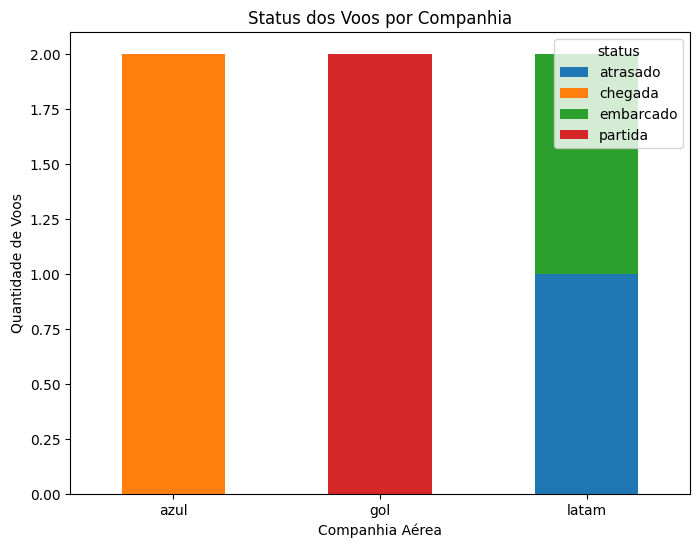

In [110]:
grafico1 = pd.crosstab(df_aero['companhia'], df_aero['status'])

grafico1.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Status dos Voos por Companhia')
plt.xlabel('Companhia Aérea')
plt.ylabel('Quantidade de Voos')
plt.xticks(rotation=0)
plt.show()

# **ESTUDO DE CASO #2**

Usando clientes_venda.csv calcule média, mediana, moda, variância, desvio padrão e IQR da coluna tempo_resposta e faça o histograma e o boxplot dessa variável.

**1ª ETAPA - Limpeza e padronização**

Mais uma vez, vou começar o estudo realizando a limpeza e padronização da tabela, assim como fiz anteriormente.

In [111]:
# Observando a tabela
df_clientes.head(10)

,nome,idade,estado,tempo_resposta,satisfacao
0,Ana,32,SP,5.4,alto
1,bruno,NaN,RJ,"7,2",médio
2,Carla,45,SP,8.0,baixo
3,daniel,-,sp,NaN,médio
4,Elisa,28,MG,6.5,alto
5,felipe,39,MG,7.1,baixo
6,Gabriela,51,RJ,"6,8",médio
7,henrique,23,SP,5.9,alto
8,Iara,NaN,SP,7.5,médio
9,joao,34,mg,"7,3",baixo


In [112]:
# Resolvendo o problema da falta de padronização
for i in df_clientes.columns:
  df_clientes[i] = df_clientes[i].str.lower().str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Padronizando números com vírgula para ponto
df_clientes['tempo_resposta'] = df_clientes['tempo_resposta'].str.replace(',', '.').astype(float)

# OBSERVAÇÃO: Como vou apenas realizar cálculos da coluna "tempo_resposta",
#             não vou corrigir as células nulas de "idade", uma vez que será desnecessário.


In [113]:
# Observando a tabela novamente
df_clientes.head(10)

,nome,idade,estado,tempo_resposta,satisfacao
0,ana,32,sp,5.4,alto
1,bruno,NaN,rj,7.2,medio
2,carla,45,sp,8.0,baixo
3,daniel,-,sp,NaN,medio
4,elisa,28,mg,6.5,alto
5,felipe,39,mg,7.1,baixo
6,gabriela,51,rj,6.8,medio
7,henrique,23,sp,5.9,alto
8,iara,NaN,sp,7.5,medio
9,joao,34,mg,7.3,baixo


**2ª ETAPA - Cálculos Estatísticos**

Agora, vou calcular média, moda, mediana, variância, desvio padrão e IQR da coluna tempo_resposta.

In [114]:
media = df_clientes['tempo_resposta'].mean() # MÉDIA
moda = df_clientes['tempo_resposta'].mode() # MODA
mediana = df_clientes['tempo_resposta'].median() # MEDIANA
variancia = df_clientes['tempo_resposta'].var() # VARIÂNCIA
desvio_padrao = np.sqrt(variancia) # DESVIO PADRÃO

# Encontrando o IQR
Q1 = df_clientes['tempo_resposta'].quantile(0.25)
Q3 = df_clientes['tempo_resposta'].quantile(0.75)
IQR = Q3 - Q1

print("DADOS DE TEMPO_RESPOSTA")
print()
print(f"MÉDIA: {media:.2f}")
print("MODA: O conjunto é amodal")
print("MEDIANA: ", mediana)
print(f"VARIÂNCIA: {variancia:.2f}")
print(f"DESVIO PADRÃO: {desvio_padrao:.2f}")
print(f"O Primeiro Quartil (Q1) é: {Q1}")
print(f"O Terceiro Quartil (Q3) é: {Q3}")
print(f"O Intervalo Interquartil (IQR) é: {IQR:.2f}")

DADOS DE TEMPO_RESPOSTA

MÉDIA: 6.86
MODA: O conjunto é amodal
MEDIANA:  7.1
VARIÂNCIA: 0.66
DESVIO PADRÃO: 0.81
O Primeiro Quartil (Q1) é: 6.5
O Terceiro Quartil (Q3) é: 7.3
O Intervalo Interquartil (IQR) é: 0.80


**3ª ETAPA - Gráficos**

Por fim, irei fazer o boxplot e histograma de tempo_resposta.

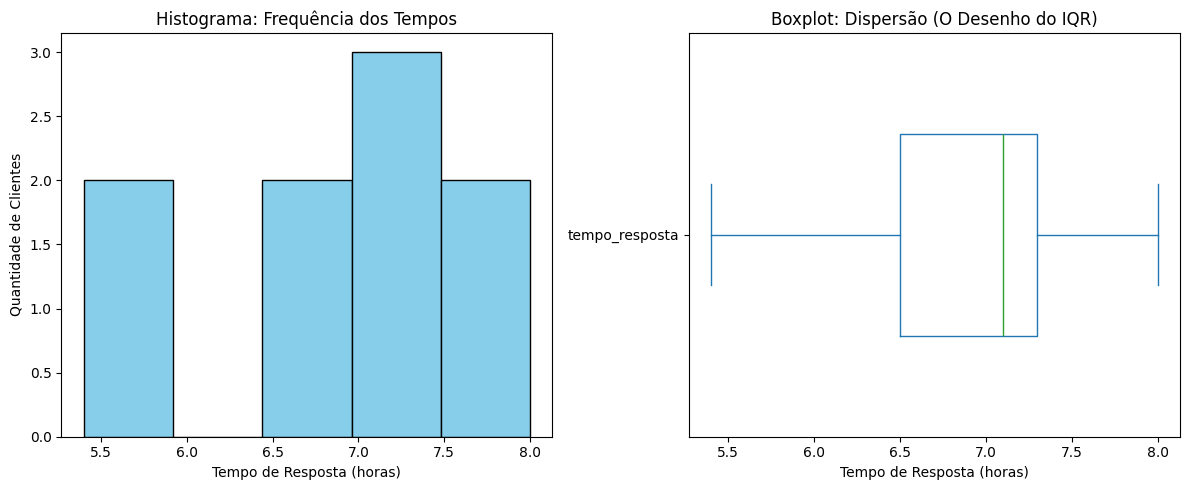

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
df_clientes['tempo_resposta'].plot(kind='hist', bins=5, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Histograma: Frequência dos Tempos')
axes[0].set_xlabel('Tempo de Resposta (horas)')
axes[0].set_ylabel('Quantidade de Clientes')

# Boxplot
df_clientes['tempo_resposta'].plot(kind='box', ax=axes[1], vert=False, widths=0.5)
axes[1].set_title('Boxplot: Dispersão (O Desenho do IQR)')
axes[1].set_xlabel('Tempo de Resposta (horas)')

plt.tight_layout()
plt.show()